In [4]:
# All imports used in the coursework
# If the import is not here, there is a custom implementation (Standard Scalar)
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [5]:
STUDENT_ID = 42 # Constant for random data split


In [6]:
# Get the dataframe from glass.data and assign column names and target names
df = pd.read_csv('glass.data', names=["Id", "RI","Na","Mg","Al","Si","K","Ca","Ba","Fe", "Class Type"])
target_names = ['building_windows_float_processed', "building_windows_non_float_processed", "vehicle_windows_float_processed", "vehicle_windows_non_float_processed", "containers", "tableware", "headlamps"]

Retrieve the dataset from the "glass.data" textfile.
Retrieve the category names for the dataset.

```df``` = Entire "glass" Dataset.

```target_names``` = All Categories of "glass" dataset.

In [7]:
# Split the data into features and target variable
X = df.drop(columns=["Id", "Class Type"])
y = df["Class Type"]

Define ```X``` and ```y``` as the data and corresponding category/class_type respectively.

In [8]:
# Split Data
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=STUDENT_ID, stratify=y)
x_train, x_validate, y_train, y_validate = train_test_split(x_temp, y_temp, test_size=0.25, random_state=STUDENT_ID, stratify=y_temp)  

Split the data into three sections.

```x_test``` ```y_test``` : Used to test the model.

```x_train``` ```y_train``` : Used to train the model.

```x_validate``` ```y_validate``` : Used to fine-tune the model.

# Custom KNN Implementation

Feature scaling implemented via standardisation. Only used for KNN as Decision trees and naive bayes does not use scaled data

Uses the ```x_train``` dataframe to get a mean and standard diviation, replaces 0 with 1 in ```x_std``` and then standardises ```x_train```,```x_test```, and ```x_validate```

In [9]:
# # Feature Scaling via standardisation
x_mean = x_train.mean() # Calculate the mean of the training data for each feature
x_std = x_train.std() + 1e-9 # Add small value to avoid division by zero

# Scale the datasets using the mean and standard deviation
x_train_scaled = ((x_train - x_mean) / x_std).to_numpy() # Scale training data
x_test_scaled = ((x_test - x_mean) / x_std).to_numpy() # Scale test data
x_validate_scaled = ((x_validate - x_mean) / x_std).to_numpy() # Scale validation data

In [10]:
class knn_classifier:
    k = 1
    x_train_data = None
    y_train_data = None
    distance_list = []

    # Construct the KNN model with inilial k value
    def __init__(self, init_k = -1):
        if (init_k >= 1):
            self.k = init_k
            return
    
    # Store the training data for distance calulcations
    def fit(self, x, y):
        self.x_train_data = x
        self.y_train_data = y

    # Calculate the Euclidean distance metric between a test row and all training rows
    # Returns a sorted list of distances
    # Euclidean distance = the sum of the squared differences between the features
    def euclidean_squared_distance(self, test_row):
        self.distance_list = []
        # Iterate through each training row
        for i in range (len(self.x_train_data)):

            distance = 0.0
            train_row = self.x_train_data[i]
            # Iterate through each feature of training row
            for y in range(len(train_row)):
                distance += (test_row[y] - train_row[y]) ** 2 # Calculate distance

            self.distance_list.append((i, distance))
        self.distance_list.sort(key=lambda x: x[1]) # Sort distances in ascending order

    # Calculate the Manhattan distance metric between a test row and all training rows
    # Returns a sorted list of distances
    # Manhattan distance = the sum of the absolute differences between the features in the test and training data
    def manhattan_distance(self, test_row):
        self.distance_list = []
        # Iterate through each training row
        for i in range (len(self.x_train_data)):

            distance = 0.0
            train_row = self.x_train_data[i]
            # Iterate through each feature of training row
            for y in range(len(train_row)):
                distance += abs((test_row[y] - train_row[y])) # Calculate the absolute difference and sum across all features

            self.distance_list.append((i, math.sqrt(distance)))
        self.distance_list.sort(key=lambda x: x[1]) # Sort the distance list in ascending order

    # Calculates the maximum distance metric between a test row and all training rows
    # Returns a sorted list of distances
    # Maximum distance = the largest absolute difference between any feature in the test and training data
    def maximum_distance(self, test_row):
        self.distance_list = []
        for i in range (len(self.x_train_data)):

            distance = 0.0
            train_row = self.x_train_data[i]

            # Iterate through each feature of training row to get maximum distance
            for y in range(len(train_row)):
                temp_distance = abs((test_row[y] - train_row[y])) # Absolute difference between the test and training feature value
                distance = max(distance, temp_distance) # Get the maximum distance across all features

            self.distance_list.append((i, math.sqrt(distance))) 
        self.distance_list.sort(key=lambda x: x[1]) # Sort the distance list in ascending order

    # Get the k nearest neighbors based on calculated distances
    def get_nearest_neighbors(self):
        neighbors_list = []
        # Iterate through all sorted distances to get closest k neighbors
        for i in range (self.k):
            row_num = self.distance_list[i][0]
            y = self.y_train_data.iloc[row_num]
            neighbors_list.append(y)
        return neighbors_list

    # Given a row, predict the class by getting nearest neighbors and returning the most common class among them
    # Distance metric is set during initialisation
    def predict_classification(self, test_row):
        self.maximum_distance(test_row)
        neighbors = self.get_nearest_neighbors()
        prediction = max(neighbors, key=neighbors.count)
        return prediction

    # Using x and y as validation data, test different values of k
    # The best k value is chosen based on the highest accuracy
    def best_k(self, x, y):
        best_accuracy = 0
        best_k_value = None

        # Test for all odd values of k between 1 and 11
        for newK in range(1, 11, 2): # Odds only
            self.k = newK
            predictions = []

            # Iterate through each row and predict the class
            for x_item in x:
                prediction = self.predict_classification(x_item)
                predictions.append(prediction)
                npPredictions = np.array(predictions)
            
            # Calculate accuracy for current k
            accuracy = np.mean(npPredictions == y.values) * 100

            # Update best k value if current accuracy is better
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_k_value = newK

        # If no k value is found, default to k=3
        if best_k_value is not None:
            self.k = best_k_value
        else:
            self.k = 3

Train the model with the training dataset and find best k with the valiation set. All datasets are scaled using standard diviation to ensure classes are somewhat even. Time is recorded in ```knn_times``` 0 and 1

In [11]:
# Train start, train end, test start, test end
knn_times = []

knn_model = knn_classifier()
knn_times.append(time.time()) # Log training start time
knn_model.fit(x_train_scaled, y_train)
knn_model.best_k(x_validate_scaled, y_validate)
knn_times.append(time.time()) # Log training end time

After training and validation sets are used to train the model and hypertune K, test the model with the test split. 

Time is recorded in ```knn_times``` as 2 and 3

In [12]:
knn_test_predictions = []
test_actual = []

knn_times.append(time.time()) # Log testing start time
for i in range(len(x_test_scaled)):
    prediction = knn_model.predict_classification(x_test_scaled[i])
    knn_test_predictions.append(prediction)
    test_actual.append(y_test.iloc[i])
knn_times.append(time.time()) # Log testing end time

accuracy_knn = np.mean(np.array(knn_test_predictions) == y_test) * 100

Display the confusion matix for the KNN model

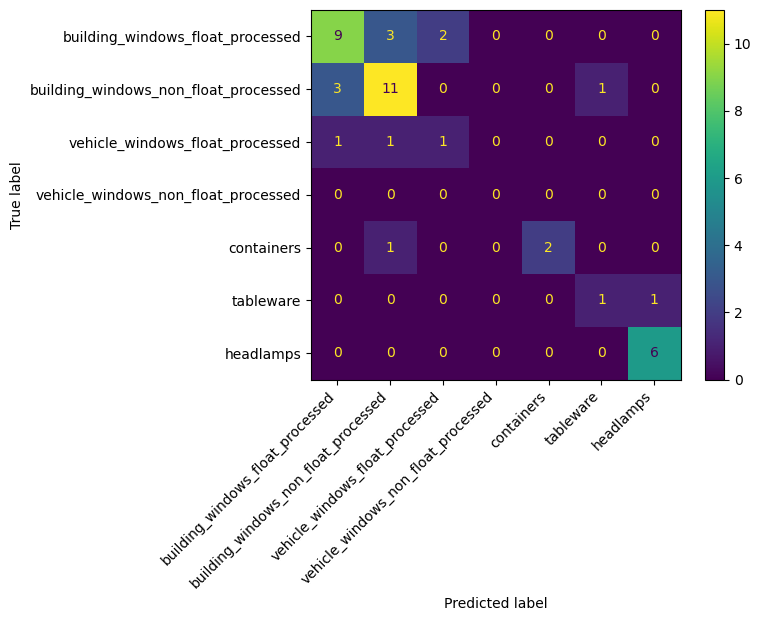

In [13]:
# Create and display the confusion matrix
cm = confusion_matrix(y_true=test_actual, y_pred=knn_test_predictions, labels=[1,2,3,4,5,6,7])
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names) # Set labels on the confusion matrix
cm_display.plot()
plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right") # Rotate x-axis labels for better readability
plt.show() 

# Custom Decision Trees Implementation

In [14]:
# Represents a node in the decision tree, which can be either a decision node or a leaf node
# Stores all values relevant to a node
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

        # Leaf Node Value
        self.value = value

In [15]:
class decisionTreeClassifier:

    # Constructor to initialize the maximum depth and minimum samples per split for this decision tree
    def __init__(self, max_depth = 6, min_samples_split = 2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    # Store the training data and build the initial tree using the training data
    def fit(self, x, y):
        self.x_train_data = x
        self.y_train_data = y
        self.rootNode = self.build_tree(x, y)

    # Calculate the Gini impurity for a given set of labels.
    def gini_impurity(self, y):
        probability = (np.bincount(y) / len(y))
        gini = 1 - (np.sum(probability ** 2))
        return gini
    
    # Calculate the weighted average Gini impurity for a split given the left and right splits.
    def gini_weight_average(self, y, y_left, y_right):
        left_gini = self.gini_impurity(y_left)
        right_gini = self.gini_impurity(y_right)
        average = ((len(y_left) * left_gini) + (len(y_right) * right_gini)) / len(y)
        return average

    # Splits a given dataset into left and right splits based on a feature and threshold value
    # Returns left and right splits of x and y
    def split(self, x, y, feature, threshold):
        mask = x[:, feature] <= threshold
        x_left = x[mask]
        y_left = y[mask]
        x_right = x[~mask]
        y_right = y[~mask]

        return x_left, y_left, x_right, y_right

    # Builds an iteration of the tree based on gini impurity, feature, and threshold values
    # Recursive function
    def build_tree(self, x, y, current_depth=0):
        
        # Default values for best gini impurity, best threshold, and best feature
        best_gini = 1000000
        best_threshold = None
        best_feature = None

        # The number of samples and features in the current dataset
        n_samples, n_features = x.shape

        # Check if the current recursion is at maximum depth or other termination condition is met
        # Returns a leaf node if the condition is met
        if current_depth == self.max_depth or n_samples < self.min_samples_split or len(np.unique(y)) == 1:
            node = Node(feature=best_feature, threshold=best_threshold, value=np.bincount(y).argmax())
            return node

        # Iterate through each feature and threshold values to find the best split based on the Gini impurity
        for i in range(n_features):
            for threshold in np.unique(x[:, i]):
                # Split the data based on the current feature and threshold
                mask = x[:, i] <= threshold
                y_left = y[mask]
                y_right = y[~mask]
                # Get the weighted average of the split using gini impurity
                gini_avg = self.gini_weight_average(y, y_left, y_right)

                # Set values if the average is better than the best gini impurity found
                if gini_avg < best_gini:
                    best_gini = gini_avg
                    best_threshold = threshold
                    best_feature = i

        # Split the data using the best feature and threshold values into left and right sets
        x_first_split, y_first_split, x_second_split, y_second_split = self.split(x, y, best_feature, best_threshold)

        # If the split is empty, return a leaf node
        if len(y_first_split) == 0 or len(y_second_split) == 0:
            return Node(feature = best_feature, threshold = best_threshold, value=np.bincount(y).argmax())

        # Recursively build the left and right subtrees using the best feature and threshold values
        left_subtree = self.build_tree(x_first_split, y_first_split, current_depth + 1)
        right_subtree = self.build_tree(x_second_split, y_second_split, current_depth + 1)
        
        # Build a node with the best feature, best threshold values, the left subtree, and the right subtree
        node = Node(feature=best_feature, threshold=best_threshold, left=left_subtree, right=right_subtree)

        return node

    # Predict the class label for a given input of x
    # by traversing the tree from the root node to a leaf node
    # Leaf node is chosed based on the feature and threshold values of the nodes
    def predict(self, x, node):
        # If the node is a leaf node, return the value of the node.
        if node.left is None and node.right is None:
            return node.value
        
        # If the feature value of x is less than or equal to the threshold, go left, otherwise go right.
        if x[node.feature] <= node.threshold:
            return self.predict(x, node.left)
        return self.predict(x, node.right)

    def predict_classification(self, x):
            predictions = []
            # For each row in x, get the prediction from the tree.
            for row in x:
                prediction = self.predict(row, self.rootNode)
                predictions.append(prediction)
            return predictions
    
    # Hypertune max depth and min samples per split by iterating through validation set and checking for best accuracy.
    def tune_hyperparameters(self, x, y):
        best_accuracy = 0
        best_max_depth = None
        best_min_samples_split = None

        for new_depth in range(1, 11):
            for new_min_samples in range(2, 11):

                self.max_depth = new_depth
                self.min_samples_split = new_min_samples

                # Get predictions from validation set
                predictions = self.predict_classification(x)
                
                # Calculate accuracy
                accuracy = np.mean(np.array(predictions) == y) * 100

                # If accuracy is better than best accuracy, update best values.
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_max_depth = new_depth
                    best_min_samples_split = new_min_samples

        self.max_depth = best_max_depth
        self.min_samples_split = best_min_samples_split

# Convert the dataframes into numpy arrays
The implementation of decision trees and naive bayes uses numpy arrays rather than dataframes

In [16]:
# Convert data to numpy arrays
x_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()

x_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

x_validate_np = x_validate.to_numpy()
y_validate_np = y_validate.to_numpy()

Part of the criteria is the time to train the model. This is recorded in ```dt_times``` \[Training Start Time, Training End Time, Testing Start Time, Testing End Time\].

The time taken to train the model then test the model attributes to the efficiency of the implementation.

In [17]:
# Train start, train end, test start, test end
dt_times = []

# Create an instance of decisionTreeClassifier and fit the model with training data
decisionTreeModel = decisionTreeClassifier()

dt_times.append(time.time()) # Log training start time
decisionTreeModel.fit(x_train_np, y_train_np)

# Tune hyper parameters using the validation set
decisionTreeModel.tune_hyperparameters(x_validate_np, y_validate_np)
dt_times.append(time.time()) # Log training end time


After training the model on the training dataset and hypertuning the parameters with the validation set; The model needs to be tested with the testing set. Time is logged at the start and end of the training period as ```dt_time``` 2 and 3

In [18]:
dt_times.append(time.time()) # Log testing start time
# Test the model using the test set and display the confusion matrix with the accuracy
dt_test_predictions = decisionTreeModel.predict_classification(x_test_np)
dt_times.append(time.time()) # Log testing end time

accuracy_dt = np.mean(np.array(dt_test_predictions) == y_test_np) * 100


# Display the confusion matrix of the model with the testing predictions and true labels

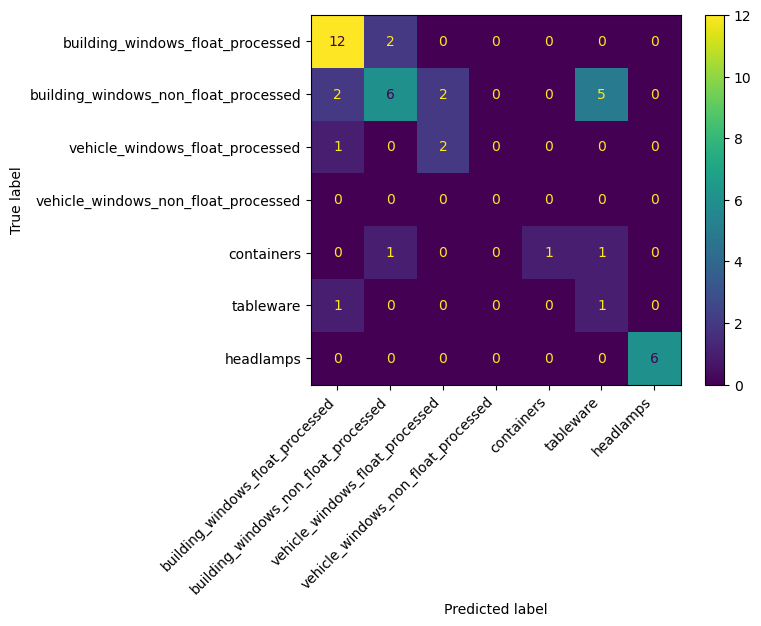

In [19]:
# Create and display the confusion matrix
cm = confusion_matrix(y_true=y_test_np, y_pred=dt_test_predictions, labels=[1,2,3,4,5,6,7])
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names)
cm_display.plot()
plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right")
plt.show()


# Custom Naive Bayes Implementation
Naive Bayes works by calculating the evidence, means, and variances of all classes during training then using this information to predict the likelihood of a data point being a part class using the Gaussian formula:
\begin{equation}
P(X|y) = \frac{1}{\sqrt{2*\pi*\sigma^2}} * e(-\frac{(x-\mu)^2}{2 * \sigma^2})
\end{equation}
The likelihood of each class is calulated for each data point inside the passed dataset. The highest likelihood is the predicted class.

The implementation includes three functions: 
- fit
    - Handles the training data, and creates the evidence, means, and variance for each class based on training data
- predict
    - Iterate through all rows in the provided dataset and define the predicted class based on the likelihood
- likelihood.
    - Iterate through all properties of x and state the probability of the x being in each class


In [20]:
class GaussianNaiveBayesClassifier:

    # Initiate the lists
    evidence = []
    means = []
    variances = []

    # Fit the model with training data
    # Calculates the mean, variance, and prior for each class
    def fit(self, x, y):
        self.n_samples, self.n_features = x.shape # Get the number of samples and features in the training data
        self.classes = np.unique(y)

        # Get the mean, variance and prior for each class
        for c in self.classes:
            x_c = x[y == c]
            self.evidence.append(x_c.shape[0] / self.n_samples)
            self.means.append(np.mean(x_c, axis=0))
            self.variances.append(np.var(x_c, axis=0))

    # Predict the class of a dataset
    def predict(self, x):
        predictions = []
        # For each row, calculate the likelhood of each class
        # The class with the highest probability is the predicted class
        for item in x:
            probabilities = []

            for i in range(len(self.classes)):
                likelihood = self.likelihood(item, i)
                probabilities.append(self.evidence[i] * likelihood)

            prediction = self.classes[np.argmax(probabilities)]
            predictions.append(prediction)

        return predictions

    # Calculate the likelihood of a row belonging to a class
    # Uses the Gaussian formula to calculate likelihood
    def likelihood(self, x, class_ids):
        likelihood = 1

        # For each feature, calculate the likelihood, and multiply them together
        for item in range(len(x)):

            # Get the mean and variance for the class and feature
            mean = self.means[class_ids][item] 
            variance = max(self.variances[class_ids][item], 1e-9) #  Avoids division error by ensuring variance is not zero

            # Gaussian formula: P(x|y) = (1 / sqrt(2 * pi * variance)) * exp(-((x - mean) ** 2) / (2 * variance))
            # Likelihood of a single class = 1/square root of (2 * pi * variance) * the exponent
            exp = np.exp(-((x[item] - mean) ** 2) / (2 * variance))
            sqrt = np.sqrt(2 * np.pi * variance) 
            likelihood *= ((1) / (sqrt)) * exp

        return likelihood


## Removing Validation Set
Naive Bayes does not require a validation set. Therefore, the training set and validation set are combined into a larger training set to increase the accuracy of the model.

In [21]:
# Combine training and validation sets
x_train_nb = np.concatenate((x_train_np, x_validate_np))
y_train_nb = np.concatenate((y_train_np, y_validate_np))

After concatenating the two sets. The classifer needs to be initiated and trained using the new dataset.

Part of the criteria is the time to train the model. This is recorded in ```nb_times``` \[Training Start Time, Training End Time, Testing Start Time, Testing End Time\].

The time taken to train the model then test the model attributes to the efficiency of the implementation.

In [22]:
# Train start, train end, test start, test end
nb_times = []

# Initiate the model and fit it with training data
naiveBayes_model = GaussianNaiveBayesClassifier()
nb_times.append(time.time()) # Log training start time
naiveBayes_model.fit(x_train_nb, y_train_nb)
nb_times.append(time.time()) # Log training end time


Once the model is trained; The model needs to be tested. This will be done using the ```x_test_np``` from Decision Trees.

Time will be record within ```nb_times``` in indexes 2 and 3

In [23]:
nb_times.append(time.time()) # Log testing start time
nb_test_predictions = naiveBayes_model.predict(x_test_np) # Get predictions for the testing dataset
nb_times.append(time.time()) # Log testing end time

# Calculate accuracy of the model using the testing predictions and the true labels
accuracy_nb = np.mean(np.array(nb_test_predictions) == y_test_np) * 100

After getting the test predictions, create a confusion matrix and plot it on a graph

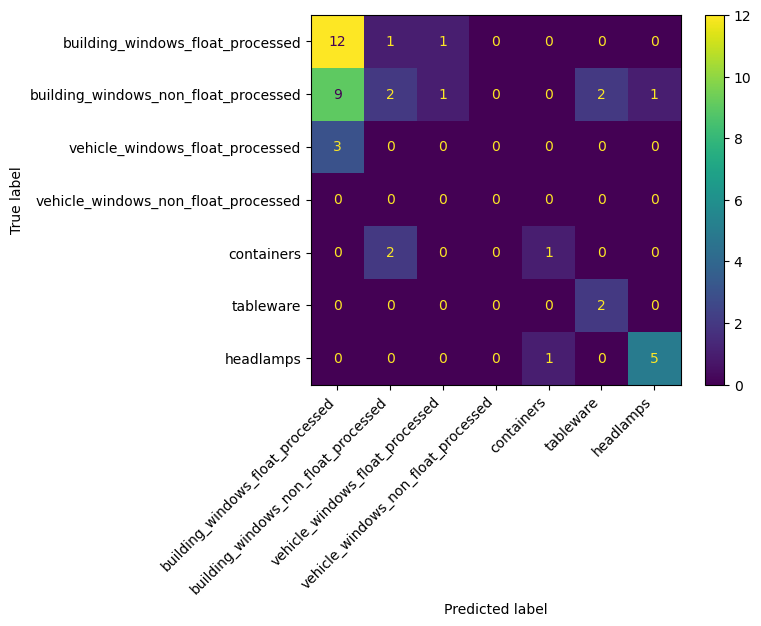

In [24]:
# Create and display the confusion matrix
cm = confusion_matrix(y_true=y_test_np, y_pred=nb_test_predictions, labels=[1,2,3,4,5,6,7])
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names)
cm_display.plot()
plt.setp(cm_display.ax_.get_xticklabels(), rotation=45, ha="right")
plt.show()

# Evaluate The Models
Using F1 score, recall, and precision. Evaluate the models for accuracy per class

In [25]:
class ClassifierEvaluation:

    # Constructor to initialize the model name, accuracy, and times
    def __init__(self, target_names):
        self.target_names = target_names

    # Calculate the F1 score for each model using
    def f1_score(self, predictions, actual):
        np_predictions = np.array(predictions)
        np_actual = np.array(actual)
        f1_scores = []

        # Iterate for all classes and calculate the F1 score for each class
        for i in range(len(self.target_names)):

            # Check if the class has any actual instances in the test set
            n_actuals = np.sum(np_actual == (i + 1)) # Get the number of actual instances of the class
            if n_actuals == 0:
                f1_scores.append("0.00%")
                continue

            # Calculate the number of true positives, false positives, and false negatives for the current class
            tp = np.sum((np_predictions == (i + 1)) & (np_actual == (i + 1))) # True Positive. Correctly predicted the class
            fp = np.sum((np_predictions == (i + 1)) & (np_actual != (i + 1))) # False Positive. Incorrectly predicted the class
            fn = np.sum((np_predictions != (i + 1)) & (np_actual == (i + 1))) # False Negative. Incorrectly predicted a different class

            # Avoid division by zero by setting tp
            if tp == 0:
                tp = 1e-9 

            # Calculate the precision and recall for the current class
            precision = tp / (tp + fp)
            recall = tp / (tp + fn)

            # Avoid division by zero. F1 would be 0 if either precision or recall is 0
            if precision == 0 or recall == 0:
                f1_scores.append("0.00%")
                continue


            # Calculate the F1 score for the current class
            f1 = round((2 * precision * recall / (precision + recall)) * 100, 2)

            f1_scores.append(str(f1) + "%")
        return f1_scores

        

# Display all information 
Display all information from the model in once place for easy viewing. Having the information spread out is difficult to view

In [26]:
evaluator = ClassifierEvaluation(target_names)
knn_f1 = evaluator.f1_score(knn_test_predictions, y_test)
dt_f1 = evaluator.f1_score(dt_test_predictions, y_test)
nb_f1 = evaluator.f1_score(nb_test_predictions, y_test)

In [27]:
# Print all Outcomes
print(f'|-----------------------------------')
print(f'| KNN Classifier Values')
print(f'|')
print(f'| Best K Value: {knn_model.k}')
print(f'| Accuracy: {float(accuracy_knn):.2f}%')
print(f'| Training Time: {knn_times[1] - knn_times[0]:.6f} seconds')
print(f'| Testing Time: {knn_times[3] - knn_times[2]:.6f} seconds')
print(f'| F1 Scores: {knn_f1}')
print(f'|-----------------------------------')
print(f'| Decision Tree Classifier Values')
print(f'|')
print(f'| Accuracy: {float(accuracy_dt):.2f}%')
print(f'| Best Max Depth: {decisionTreeModel.max_depth}')
print(f'| Best Min Samples Split: {decisionTreeModel.min_samples_split}')
print(f'| Training Time: {dt_times[1] - dt_times[0]:.6f} seconds')
print(f'| Testing Time: {dt_times[3] - dt_times[2]:.6f} seconds')
print(f'| F1 Scores: {dt_f1}')
print(f'|-----------------------------------')
print(f'| Naive Bayes Classifier Values')
print(f'|')
print(f'| Naive Bayes Accuracy: {float(accuracy_nb):.2f}%')
print(f'| Training Time: {nb_times[1] - nb_times[0]:.6f} seconds')
print(f'| Testing Time: {nb_times[3] - nb_times[2]:.6f} seconds')
print(f'| F1 Scores: {nb_f1}')
print(f'|-----------------------------------')



|-----------------------------------
| KNN Classifier Values
|
| Best K Value: 1
| Accuracy: 69.77%
| Training Time: 0.056522 seconds
| Testing Time: 0.010695 seconds
| F1 Scores: ['66.67%', '70.97%', '33.33%', '0.00%', '80.0%', '50.0%', '92.31%']
|-----------------------------------
| Decision Tree Classifier Values
|
| Accuracy: 65.12%
| Best Max Depth: 1
| Best Min Samples Split: 2
| Training Time: 0.043586 seconds
| Testing Time: 0.000149 seconds
| F1 Scores: ['80.0%', '50.0%', '57.14%', '0.00%', '50.0%', '22.22%', '100.0%']
|-----------------------------------
| Naive Bayes Classifier Values
|
| Naive Bayes Accuracy: 51.16%
| Training Time: 0.000583 seconds
| Testing Time: 0.004299 seconds
| F1 Scores: ['63.16%', '20.0%', '0.0%', '0.00%', '40.0%', '66.67%', '83.33%']
|-----------------------------------
